# Viet Dataverse API Demo — Gold Price

Gọi API giá vàng Việt Nam qua `https://api.vietdataverse.online`.

- `/api/v1/gold/types` — public, không cần key
- `/api/v1/gold?period=…&type=…` — public; gọi kèm `X-API-Key` để tính vào quota
- Premium Developer: **10K req/tháng** (`dev_monthly`) hoặc **100K** (`dev_yearly`)

## Setup

1. Tạo file `.env` một cấp **trên** thư mục chứa notebook này (ví dụ: `vietdataverse/.env` hoặc thư mục cha của nó):
   ```
   VDV_API_KEY=your_key_here
   ```
2. Lấy API key tại https://vietdataverse.online/pages/developer.html sau khi đăng ký gói Developer.
3. Nếu không có key, notebook chạy ở **public mode** — các endpoint public vẫn hoạt động bình thường.


In [1]:
# Cài deps (bỏ qua nếu đã có)
# %pip install -q requests pandas matplotlib


In [ ]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def _parse_env_file(path: Path) -> dict:
    """Parse .env — xử lý KEY=value, KEY = "value", và dòng có comment."""
    result = {}
    for line in path.read_text(encoding='utf-8').splitlines():
        line = line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, _, val = line.partition('=')
        key = key.strip()
        val = val.split('#')[0].strip().strip('"').strip("'")
        result[key] = val
    return result

# Tìm .env theo thứ tự ưu tiên (từ gần đến xa so với notebook)
_env_loaded = False
for _p in [Path('../.env'), Path('../../.env'), Path('.env')]:
    if _p.exists():
        for k, v in _parse_env_file(_p).items():
            os.environ.setdefault(k, v)
        print(f'Loaded .env from: {_p.resolve()}')
        _env_loaded = True
        break

if not _env_loaded:
    print('⚠️  Không tìm thấy .env — chạy ở public mode')
    print('   Tạo file .env với nội dung: VDV_API_KEY=your_key_here')

API_BASE    = 'https://api.vietdataverse.online'
VDV_API_KEY = os.environ.get('VDV_API_KEY', '')
headers     = {'X-API-Key': VDV_API_KEY} if VDV_API_KEY else {}
print('Auth:', 'X-API-Key ✓' if headers else 'public mode (no key)')


## 1. Danh sách loại vàng

In [2]:
r = requests.get(f"{API_BASE}/api/v1/gold/types", headers=headers, timeout=15)
r.raise_for_status()
payload = r.json()

types = payload["types"]
print(f"Tổng: {len(types)} loại")
print("\n10 mã đầu:")
for t in types[:10]:
    print("  •", t)

Tổng: 51 loại

10 mã đầu:
  • BTMC BẠC BẮC SƯ TỬ ANCARAT 999 5 LƯỢNG (ANCARAT)
  • BTMC BẠC MIẾNG BẠC RỒNG THĂNG LONG Ag 999 0,5 KG (BẠC RỒNG THĂNG LONG Ag 999)
  • BTMC BẠC MIẾNG BẠC RỒNG THĂNG LONG Ag 999 1 KG (BẠC RỒNG THĂNG LONG Ag 999)
  • BTMC BẠC MIẾNG BẠC RỒNG THĂNG LONG Ag 999 1 LƯỢNG (BẠC RỒNG THĂNG LONG Ag 999)
  • BTMC BẠC MIẾNG BẠC RỒNG THĂNG LONG Ag 999 5 LƯỢNG (BẠC RỒNG THĂNG LONG Ag 999)
  • BTMC BẠC MIẾNG PHÚ QUÝ Ag 999 1 KG 1000 GRAM (PHÚ QUÝ)
  • BTMC BẠC MIẾNG PHÚ QUÝ Ag 999 1 LƯỢNG (PHÚ QUÝ)
  • BTMC BẠC MIẾNG PHÚ QUÝ Ag 999 5 LƯỢNG (PHÚ QUÝ)
  • BTMC BẠC THỎI 2025 ANCARAT 999 0.5 KG (500 GRAM) (ANCARAT)
  • BTMC BẠC THỎI 2025 ANCARAT 999 1 KG (1000 GRAM) (ANCARAT)


## 2. Giá vàng DOJI HN — 1 tháng gần nhất

Response schema: `data: { dates: [...], buy_prices: [...], sell_prices: [...] }`

In [3]:
def fetch_gold(gold_type: str, period: str = "1m") -> pd.DataFrame:
    r = requests.get(
        f"{API_BASE}/api/v1/gold",
        params={"period": period, "type": gold_type},
        headers=headers,
        timeout=15,
    )
    r.raise_for_status()
    # In quota headers nếu có
    for h in ("X-RateLimit-Limit", "X-RateLimit-Remaining", "X-RateLimit-Reset"):
        if h in r.headers:
            print(f"{h}: {r.headers[h]}")
    d = r.json()["data"]
    df = pd.DataFrame({
        "date":       pd.to_datetime(d["dates"]),
        "buy_price":  d["buy_prices"],
        "sell_price": d["sell_prices"],
    })
    df["type"] = gold_type
    return df

df = fetch_gold("DOJI HN", "1m")
print(f"\n{len(df)} dòng | {df['date'].min().date()} → {df['date'].max().date()}")
df.head()


30 dòng | 2026-03-24 → 2026-04-22


,date,buy_price,sell_price,type
0,2026-03-24,167200000.0,170200000.0,DOJI HN
1,2026-03-25,172000000.0,175000000.0,DOJI HN
2,2026-03-26,168500000.0,171500000.0,DOJI HN
3,2026-03-27,168600000.0,171600000.0,DOJI HN
4,2026-03-28,169800000.0,172800000.0,DOJI HN


## 3. Vẽ biểu đồ mua / bán

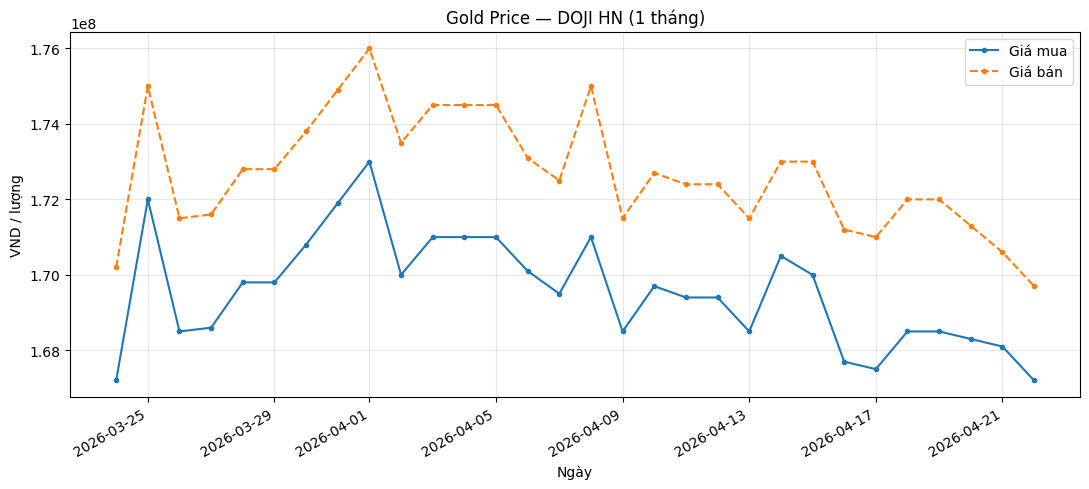

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df["date"], df["buy_price"],  marker="o", markersize=3, label="Giá mua")
ax.plot(df["date"], df["sell_price"], marker="o", markersize=3, label="Giá bán", linestyle="--")
ax.set_title("Gold Price — DOJI HN (1 tháng)")
ax.set_xlabel("Ngày")
ax.set_ylabel("VND / lượng")
ax.grid(alpha=0.3)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 4. So sánh spread giá bán giữa vài loại — 1 năm

[PNJ HCM] no data


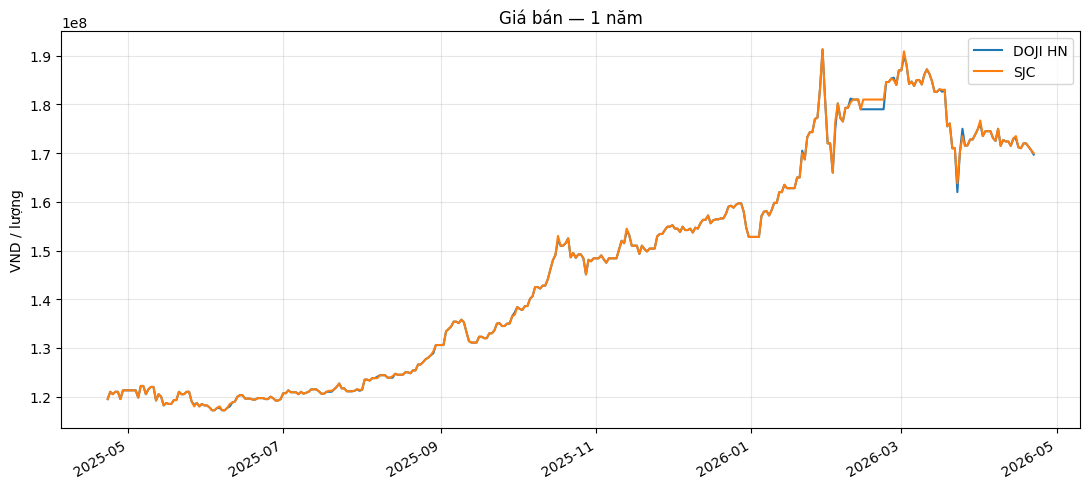

In [5]:
compare = ["DOJI HN", "SJC", "PNJ HCM"]

fig, ax = plt.subplots(figsize=(11, 5))
for gtype in compare:
    try:
        d = fetch_gold(gtype, "1y")
        if d.empty:
            print(f"[{gtype}] no data")
            continue
        ax.plot(d["date"], d["sell_price"], label=gtype)
    except requests.HTTPError as e:
        print(f"[{gtype}] {e.response.status_code}: {e.response.text[:120]}")
    except Exception as e:
        print(f"[{gtype}] {type(e).__name__}: {e}")

ax.set_title("Giá bán — 1 năm")
ax.set_ylabel("VND / lượng")
ax.grid(alpha=0.3); ax.legend(); fig.autofmt_xdate()
plt.tight_layout(); plt.show()

## 6. Demo premium endpoint (cần API key thật)

`/api/v1/gold` là **public** → gọi không cần key. Để test luồng auth + quota, dùng premium endpoint như `/api/v1/vn30/prices/{ticker}` (yêu cầu `premium_developer`).

- Không có key → 401
- Key sai → 401
- Key đúng nhưng tier free → 403
- Key đúng + `premium_developer` → 200 + quota bị trừ (header `X-RateLimit-*`)

In [ ]:
endpoint = f"{API_BASE}/api/v1/vn30/prices/VNM"

# Không key
r = requests.get(endpoint, params={"period": "7d"}, timeout=10)
print(f"[no key]   {r.status_code}: {r.text[:100]}")

# Key sai
r = requests.get(endpoint, params={"period": "7d"},
                 headers={"X-API-Key": "fake-key-abc"}, timeout=10)
print(f"[fake key] {r.status_code}: {r.text[:100]}")

# Key thật
if headers:
    r = requests.get(endpoint, params={"period": "7d"}, headers=headers, timeout=15)
    print(f"[real key] {r.status_code}")
    for h in ("X-RateLimit-Limit", "X-RateLimit-Remaining", "X-RateLimit-Reset"):
        if h in r.headers:
            print(f"  {h}: {r.headers[h]}")
    if r.ok:
        body = r.json()
        print(f"  count: {body.get('count', len(body.get('data', [])))}")
else:
    print("[real key] Chưa set API_KEY — bỏ qua")